In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import pyvista as pv
import matplotlib.pyplot as plt
from itertools import product
from tqdm import tqdm

from phd_helpers.paths import get_info_df

from helpers import (
    compute_power_law_coeffs, compute_img_metrics, compute_fe_grid_data, build_fe_data, fe_mets_from_mesh,
    F_from_path, avg_frames_from_paths, plot_comparison, plot_sensor_grids, compute_CA_overlap, save_errors,
    compute_error, compute_cop_error, compute_test_fe_error, apply_fit, compute_polynomial_coeffs, paired_parameter_sensitivity
)

from errors import Errors

In [2]:
# FE input
fea_path = Path('../../../../Computational/InpPipeline/outputs/initialFEAstuff/accuracy')
inp_file = list(fea_path.glob('study3_50017L_fle/**/*.inp'))[0]

In [43]:
info_df = get_info_df('CMC')

exp1_path = Path('../../../../Experimental/LabData/contactTesting/20260904')
exp2_path = Path('../../../../Experimental/LabData/contactTesting/20260921')

# 21/09/26
cal_paths = list(exp2_path.glob('tekscan/calibration/*.asm'))
def F_from_path2(path):
    return int(path.name[3:].split('.')[0].split('_')[0])
cal_Fs = [F_from_path2(x) for x in cal_paths]

# TESTING #
# testing on high-1
test_paths = {
    #'14548R_neu_1': list(exp1_path.glob(f'testing/14548R/neu_1*.asm')),
    #'14548R_neu_2': list(exp2_path.glob(f'tekscan/testing/14548R/neu*_1.asm')),

    '50017L_fle_1': list(exp1_path.glob(f'testing/50017L/fle_1*.asm')),
    #'50017L_fle_2': list(exp2_path.glob(f'tekscan/testing/50017L/fle*_2.asm')),

    '50017L_ext_1': list(exp2_path.glob(f'tekscan/testing/50017L/ext*_1.asm')),
    #'50017L_ext_2': list(exp2_path.glob(f'tekscan/testing/50017L/ext*_2.asm')),
}
test_Fs = {
    #'14548R_neu_1': [F_from_path(x) for x in test_paths['14548R_neu_1']],
    #'14548R_neu_2': [F_from_path2(x) for x in test_paths['14548R_neu_2']],

    '50017L_fle_1': [F_from_path(x) for x in test_paths['50017L_fle_1']],
    #'50017L_fle_2': [F_from_path2(x) for x in test_paths['50017L_fle_2']],

    '50017L_ext_1': [F_from_path2(x) for x in test_paths['50017L_ext_1']],
    #'50017L_ext_2': [F_from_path2(x) for x in test_paths['50017L_ext_2']],
}

fe_path = Path('../../../../Computational/InpPipeline/outputs/initialFEAstuff/accuracy')
inp_paths = {
    #'14548R_neu': list(fe_path.glob('study3_35T*/**/*.inp'))[0],
    '50017L_fle': list(fe_path.glob('study3_50017L_fle/**/*.inp'))[0],
    '50017L_ext': list(fe_path.glob(f'TwistTranslate/ty-00to10/**/50017L/**/*-00.inp'))[0]
}
csv_paths = {
    '50017L_fle': list(fe_path.glob(f'study3_50017L_fle/**/resultCSVs'))[0],
    '50017L_ext': list(fe_path.glob(f'TwistTranslate/ty-00to10/aire/output/resultCSVs/50017L-*-00'))[0],
}

In [44]:
fe_datas = {key: build_fe_data(inp_file, csv_paths[key]) for key, inp_file in inp_paths.items()}

In [77]:
#•••••••••••••••• PARAMETERS ••••••••••••••••#

# Calibration & Testing
sensor_id = 3
raw_mask = 3     # <= mask of raw sensor values
custom_masks = [[4, -1, 0]] # [[raw_mask_value, j_idx, k_idx], ...]
hold_time = 180 # instron hold time
avg_window = 5 # time window to average frames over

# FE
guide_wall_z = {
        '50017L_fle': 12.5,
        '50017L_ext': 11.0,
}
sensor_offset = -2
sensor_offset_y = {
        '50017L_fle': 0,
        '50017L_ext': 2,
}
bone = 'tpm'

# Calibration
cal_start_time = 60 # start time of average window relative to detected hold start
cal_F_range = (120, 500)
fit_type = ('poly', False, 3, True)

# Testing
test_start_time = 60 # start time of average window relative to detected hold start


In [78]:
errors = {}
for test_path, test_F in zip(test_paths, test_Fs):
    test_1_paths = test_paths[test_path]
    test_1_Fs = test_Fs[test_F]
    fe_data = fe_datas[test_path[:-2]]

    sub = test_path.split('_')[0]
    tpm_vol = info_df['tpm_volume'][(info_df['subject'].astype(str)+info_df['side'] == sub)].values[0]
    use_F2_test = True if test_path != '50017L_fle_1' else False
    
    def_errors = Errors(
                fe_data=fe_data, 
                common_Fs = set(fe_data) & set(test_1_Fs), 
                cal_F_range=cal_F_range,
                cal_1_Fs=cal_Fs,
                cal_1_paths=cal_paths,
                test_1_Fs=test_1_Fs,
                test_1_paths=test_1_paths,
                sensor_id=sensor_id, 
                raw_mask=raw_mask, 
                custom_masks=custom_masks, 
                hold_time=hold_time, 
                avg_window=avg_window, 
                cal_start_time=cal_start_time, 
                test_start_time=test_start_time, 
                guide_wall_z=guide_wall_z[test_path[:-2]], 
                sensor_offset_y=sensor_offset_y[test_path[:-2]],
                sensor_offset=sensor_offset, 
                bone=bone,
                bone_vol=tpm_vol,
                fit_type=fit_type,
                use_F2_test=use_F2_test,
                use_F2_cal=True,
            )
    errors[test_path] = def_errors

{'P_max': {'bias': np.float64(-1.0020725540035436),
  'mae': np.float64(1.019982285141559),
  'mpe': np.float64(-18.545900987182414),
  'mape': np.float64(20.870177594973168),
  'max_ape': (np.float64(7.180472861364895), np.float64(32.07266123821366)),
  'rmse': np.float64(1.3039958086250039),
  'nrmse_mean_%': np.float64(33.83412070492698)},
 'P_avg': {'bias': np.float64(-0.1360137762373834),
  'mae': np.float64(0.1360137762373834),
  'mpe': np.float64(-12.599033919624844),
  'mape': np.float64(12.599033919624844),
  'max_ape': (np.float64(0.5793991172901858), np.float64(19.823356524513482)),
  'rmse': np.float64(0.1630688296291667),
  'nrmse_mean_%': np.float64(16.839898934763468)},
 'CA': {'bias': np.float64(-9.946216666666666),
  'mae': np.float64(10.483849999999999),
  'mpe': np.float64(-17.01864929833106),
  'mape': np.float64(18.68531596499772),
  'max_ape': (np.float64(69.3547), np.float64(34.883720930232556)),
  'rmse': np.float64(13.053533615653654),
  'nrmse_mean_%': np.floa

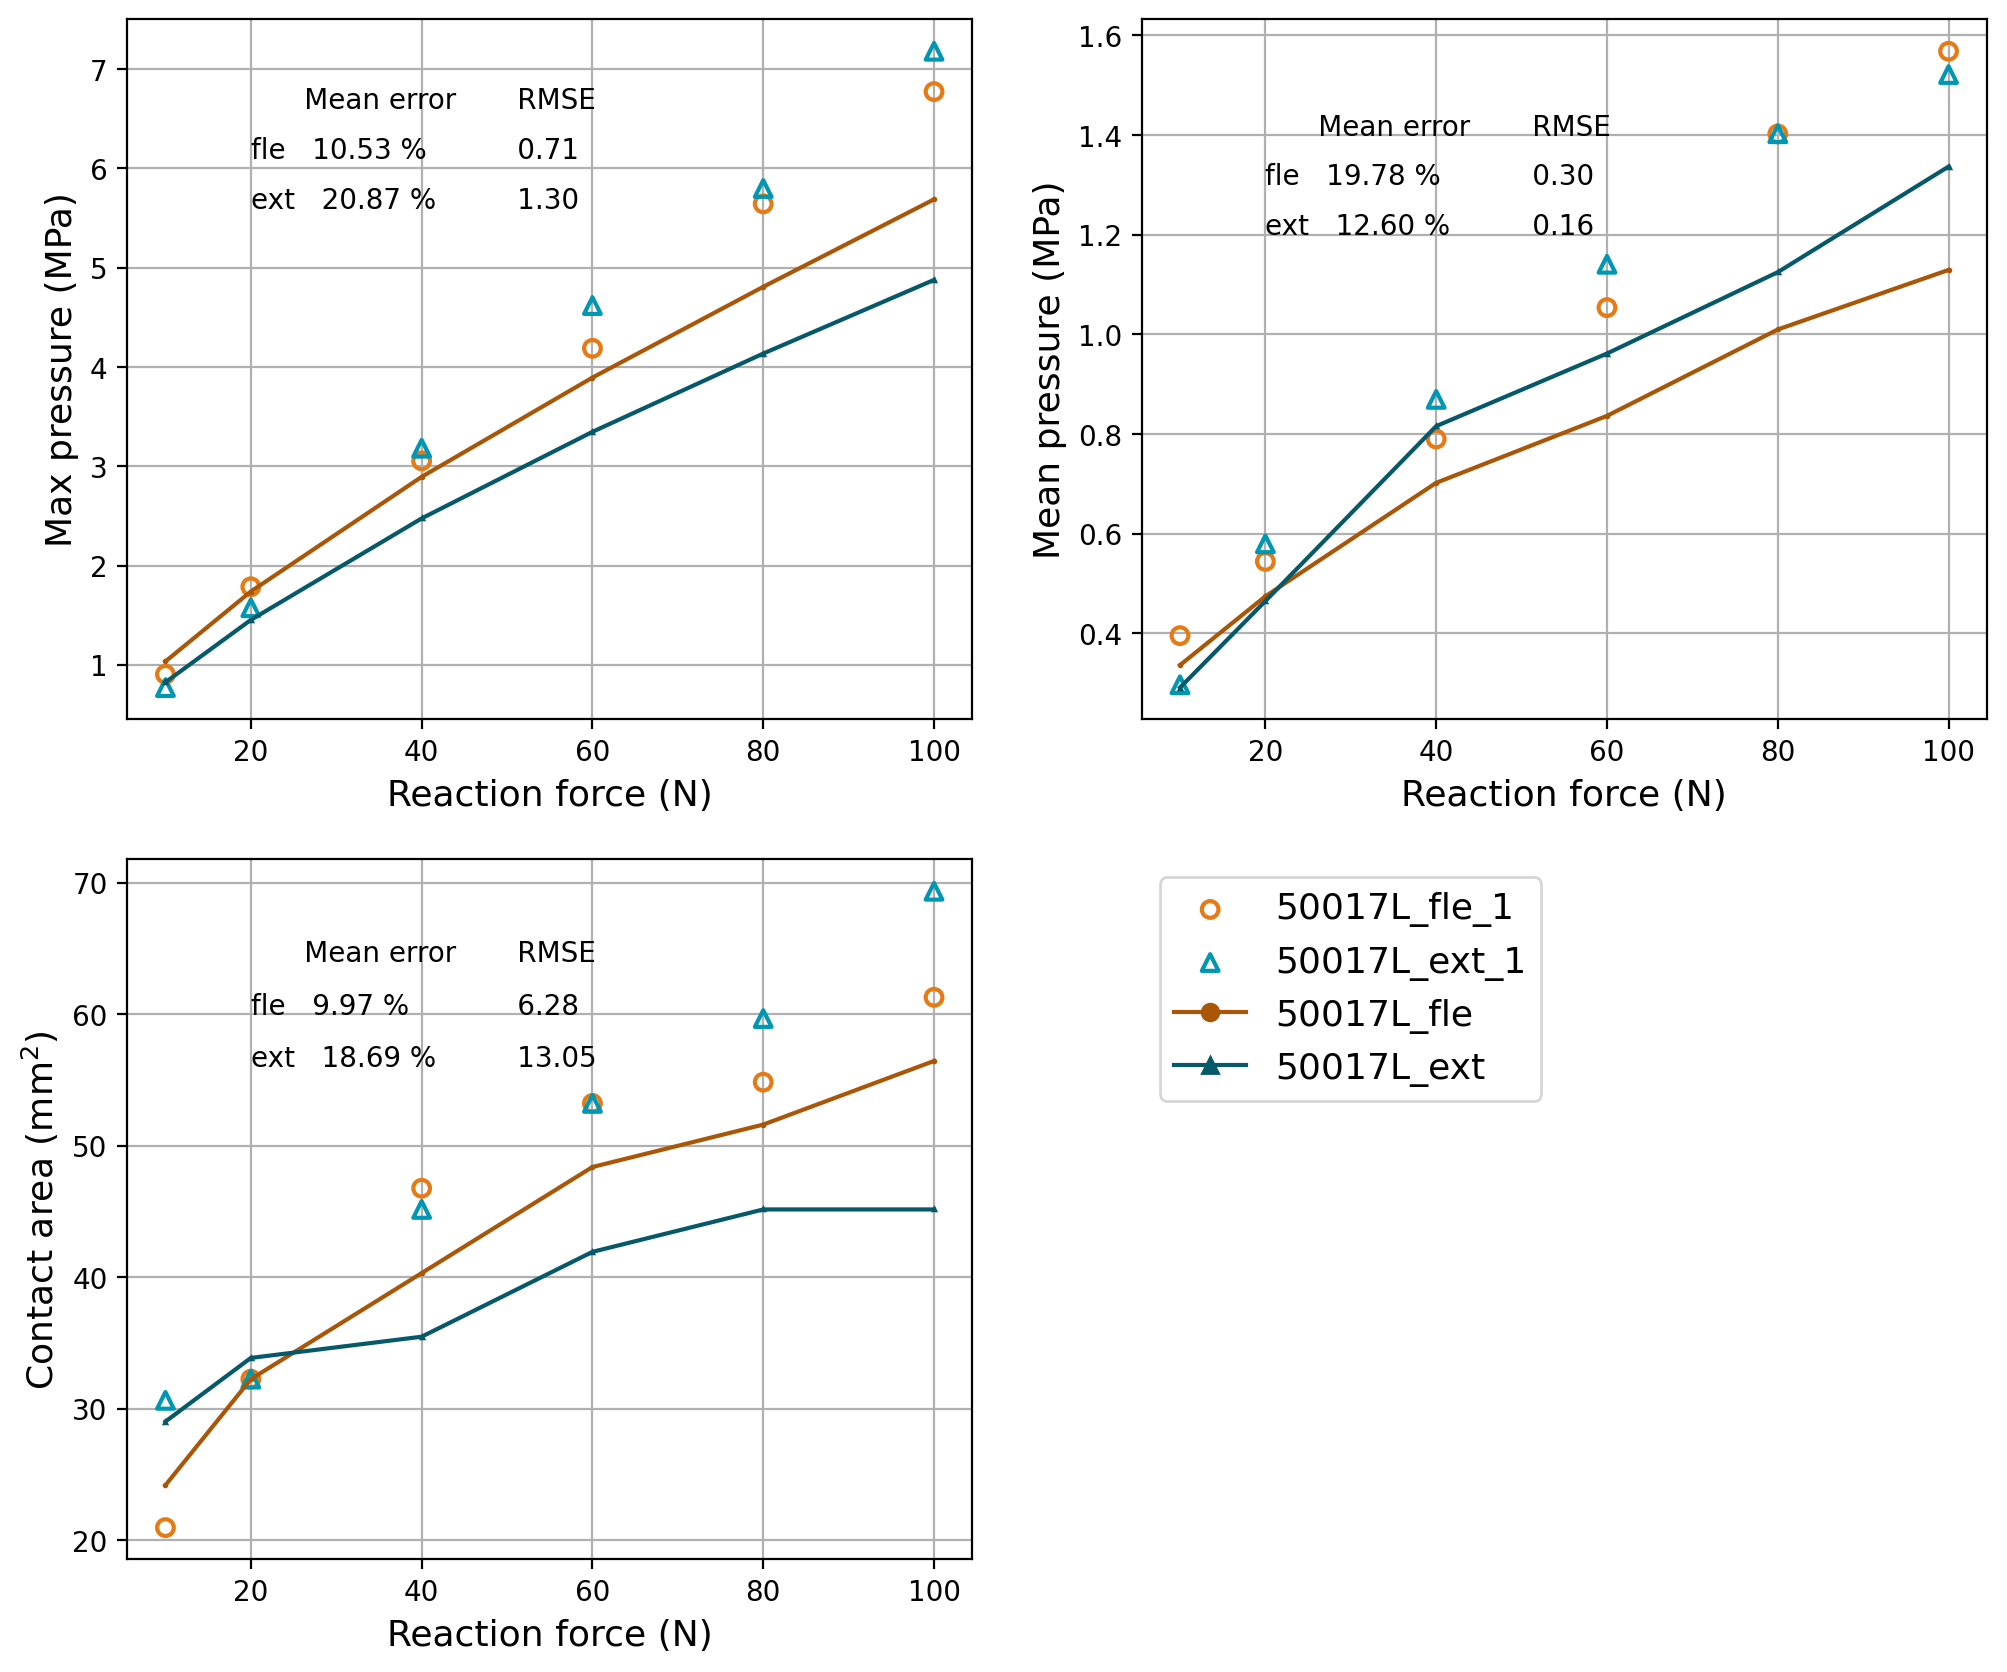

In [117]:
nrows, ncols = 2, 2
fig, ax = plt.subplots(nrows, ncols, figsize=(ncols*6, nrows*5), dpi=200)

ax = ax.flatten()


fs = 13
colors = {
    #"14548R_neu": "#cc79a7",
        #"#009e73"
    "50017L_fle": "#e67a14",
    '50017L_ext': "#0097b2",
        #"#cc79a7"
        #"#bfb200"
    "ext": "#065968",
    "fle": "#aa5607",
    }
markers = {
    "fle": "o", 
    "ext": "^",
    #'50017L_ext': "S"
}

mets = ['P_max', 'P_avg', 'CA']
for mets_label, error in errors.items():
    mets_data = error.test_mets
    
    x = np.array(sorted(list(mets_data.keys())))
    x = x[x <= 100]
    for i, met in enumerate(mets):
        y = [mets_data[f][met] for f in x]
        ax[i].scatter(
            x, y,
            facecolors='none',
            edgecolors=colors[mets_label[:-2]],
            linewidths=1.5,
            marker=markers[mets_label.split('_')[1]],
            label=mets_label,
            zorder=2
        )
    ax[3].scatter([],[],facecolors='none',edgecolors=colors[mets_label[:-2]],linewidths=1.5,marker=markers[mets_label.split('_')[1]],label=mets_label)
        #ax[2].errorbar(F, tek_mets['CA'], yerr=[[tek_mets['CA_e_low']], [tek_mets['CA_e_high']]] , c=colors['tek'], marker=markers['tek'], capsize=5, elinewidth=0.8)

error_mets = ['mape', 'rmse']
error_x = 20
x_off = 25
error_y = {'P_max': 6.1,'P_avg': 1.3,'CA': 60}
error_off = {'P_max': 0.5,'P_avg': 0.1,'CA': 4}
for j, (mets_label, error) in enumerate(errors.items()):
    if mets_label[-1] == '2':
        continue
    mets_data = error.fe_grid_mets
    
    x = np.array(sorted(list(mets_data.keys())))
    x = x[x <= 100]
    for i, met in enumerate(mets):
        y = [mets_data[f][met] for f in x]
        ax[i].plot(
            x, y,
            color=colors[mets_label.split('_')[1]],
            linewidth=1.5,
            markersize=1,
            marker=markers[mets_label.split('_')[1]],
            label=mets_label,
            zorder=2
        )

        met_errors = errors[mets_label].errors['fe_grid_error']
        ax[i].annotate(f'{mets_label.split('_')[1]}   {met_errors[met]['mape']:.2f} %', (error_x, error_y[met]-(error_off[met]*j)))
        ax[i].annotate(f'      {met_errors[met]['rmse']:.2f}', (error_x+x_off, error_y[met]-(error_off[met]*j)))
        if j==1:
            ax[i].annotate(f'      Mean error', (error_x, error_y[met]+(error_off[met]*j)))
            ax[i].annotate(f'      RMSE', (error_x+x_off, error_y[met]+(error_off[met]*j)))

    ax[3].plot([],[],color=colors[mets_label.split('_')[1]],linewidth=1.5,marker=markers[mets_label.split('_')[1]],label=mets_label[:-2])


#for f in x:
#    ax[3].scatter(f, compute_CA_overlap(fe_grid_data[f], test_frames_mpa[f]), c="#009e73", marker="D")

ax[0].set_ylabel('Max pressure (MPa)', fontsize=fs)
ax[1].set_ylabel('Mean pressure (MPa)', fontsize=fs)
ax[2].set_ylabel('Contact area (mm$^2$)', fontsize=fs)
#ax[3].set_ylabel('Contact area overlap %', fontsize=fs)
ax[3].axis('off')
for ax_i in ax[:-1]:
    ax_i.set_xlabel('Reaction force (N)', fontsize=fs)
    ax_i.grid()
ax[3].legend(fontsize=fs, loc='upper left')
#ax[3].legend(fontsize=fs)
plt.show()

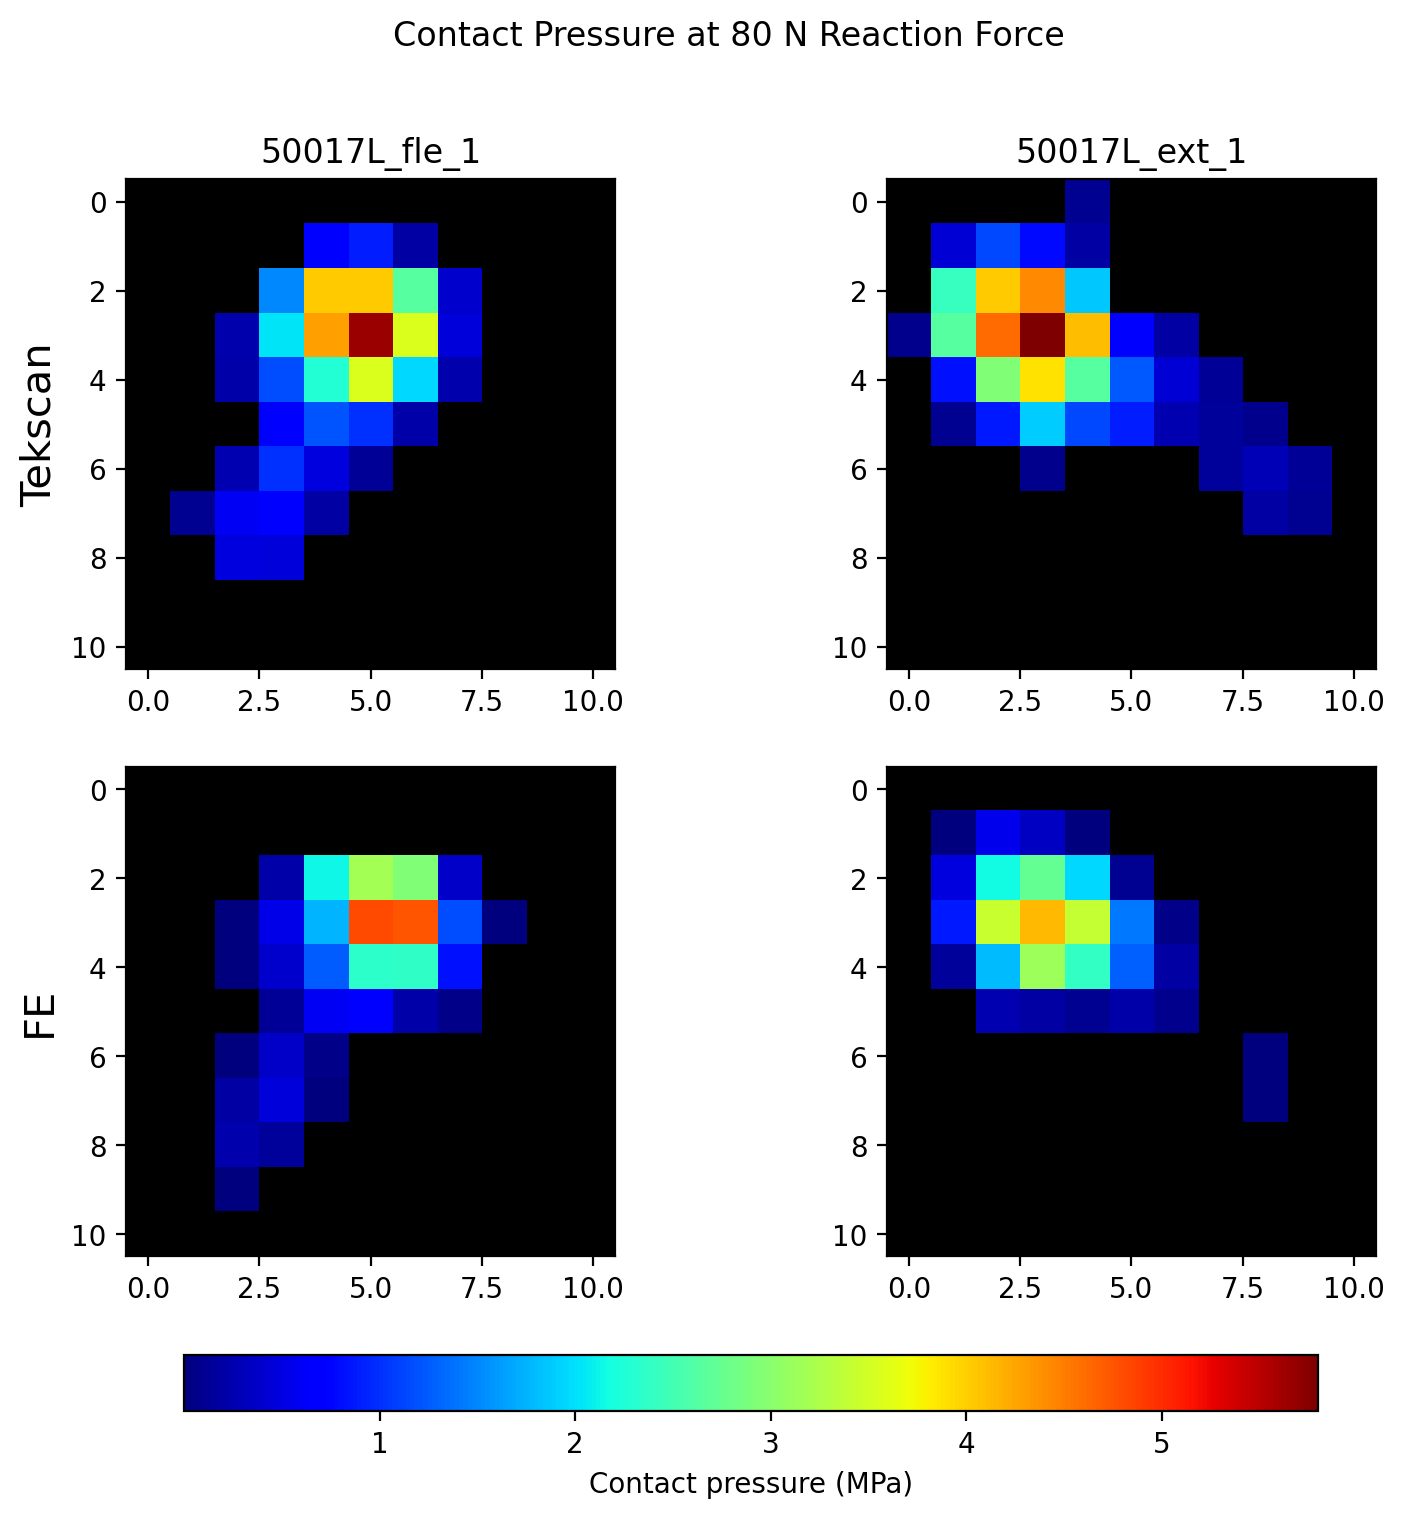

In [80]:
F = 80

j1 = f'50017L_fle_1'
j2 = f'50017L_ext_1'

nrows, ncols = 2, 2
fig, ax = plt.subplots(nrows, ncols, figsize=(4.5*ncols, 4*nrows), dpi=200)
ax = ax.flatten()

grids = [
    errors[j1].test_frames_mpa[F][::-1], 
    errors[j2].test_frames_mpa[F][::-1], 
    errors[j1].fe_grid_data[F][::-1], 
    errors[j2].fe_grid_data[F][::-1]
]

press_min = np.min( [np.min(grid) for grid in grids] )
press_max = np.max( [np.max(grid) for grid in grids] )
clims = (1e-5, press_max)

# imshows
cmap = plt.cm.jet.copy()
cmap.set_under('black')
for i, grid in enumerate(grids):
    im = ax[i].imshow(grid, vmin=clims[0], vmax=clims[1], cmap=cmap)

    # peak pressure loc
    y, x = compute_img_metrics(grid)['COP']
    #ax[i].scatter(x, y, color="#cc79a7", s=10, marker='x')

ax[0].set_title(j1)
ax[1].set_title(j2)
ax[0].set_ylabel('Tekscan', fontsize=15)
ax[2].set_ylabel('FE', fontsize=15)
fig.suptitle(f'Contact Pressure at {F} N Reaction Force')

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.08, orientation='horizontal')
cbar.set_label('Contact pressure (MPa)')

plt.show()